In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

coefs = pd.read_csv('data/mle_coef_fits_lapse_not_fitted.csv',index_col=0)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set_style('ticks')
sns.set_context('paper',font_scale=2.5)

In [4]:
coefs.head()

,id,mema_count,fit_var,z11,z21,z31,z41,z51,z61,z71,z81,z91,z101,z12,z22,z32,z42,z52,z62,z72,z82,z92,z102,a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,r1,r2,r3,r4,r5,r6,r7,r8,r9,b11,b22,u1,u2
1,1,64,False,0.060700,0.162774,0.139974,0.022603,-0.041837,0.000768,0.011361,0.009715,-0.000728,-1.415549e-09,-0.000644,-0.001176,-0.000726,0.006007,0.001080,0.002063,-0.003309,-0.002704,-0.000853,-1.000000e-10,0.448022,0.967189,0.900802,0.697382,0.361793,0.489083,0.428576,0.470672,0.345068,-1.198831e-08,0.020278,0.004633,0.016153,0.027730,0.015990,0.016549,0.004421,0.001926,0.001483,0.071488,0.919210,-4.408568,-5.011249
2,2,77,False,0.171812,0.002734,0.226519,0.044104,-0.068628,-0.012099,-0.005168,0.008832,0.006653,3.270645e-02,0.004763,-0.001043,0.003586,0.021422,0.008646,0.014502,0.019416,0.021500,0.017920,5.589629e-03,0.127873,0.006646,0.207674,0.179616,0.499017,0.545440,0.493280,0.676518,0.204164,5.414590e-02,0.015939,0.000161,0.001517,0.021598,0.018206,0.023599,0.007105,0.003915,0.007198,0.091524,0.962739,-0.370014,0.071122
3,3,87,False,0.117196,0.037579,0.213961,-0.107528,-0.141637,0.001972,0.079017,0.038151,0.022992,-2.053649e-02,0.001502,0.004093,0.013020,0.012786,-0.003353,0.013120,-0.006286,0.036277,-0.006758,-1.200174e-02,0.206253,-0.002874,-0.003012,0.559453,0.884296,0.218227,0.461748,0.339866,0.268192,2.375796e-01,0.051623,0.015994,0.031225,0.052101,0.023015,0.066293,0.043277,0.009193,0.013344,0.281290,0.968107,0.841327,0.451530
4,5,90,False,0.047633,0.115157,0.064370,-0.035042,-0.017845,-0.083632,0.085296,0.097173,-0.095015,1.000000e-10,0.093893,0.150773,0.004036,-0.032682,-0.031548,0.044687,-0.040876,-0.085049,0.081828,1.000000e-10,0.121171,0.120521,0.468761,0.512187,0.615355,0.420314,0.707571,0.750145,0.121950,-2.367804e-10,0.031999,0.000224,0.023929,0.031405,0.065940,0.063762,0.014699,0.013565,0.011183,0.432513,0.152261,0.561259,1.210596
5,6,79,False,0.151504,0.117465,0.112857,-0.043568,-0.030870,0.063162,0.004779,0.004082,0.007050,-1.000000e-10,0.059346,0.150084,-0.090832,0.000620,0.009457,-0.061310,0.030179,0.003893,0.001976,1.579344e-10,0.374597,0.027997,0.836611,0.188654,0.351104,0.731966,0.805255,0.969313,0.128049,-6.286058e-10,0.012887,0.009826,0.023153,0.046266,0.012176,0.028207,0.005917,0.002164,0.002115,0.564736,0.065833,-0.785778,2.716675


E[b11] = 0.24615074597830336
E[b22] = 0.6807922688258696


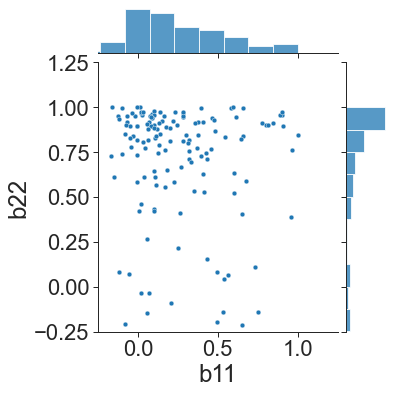

In [5]:
# Hidden State B diagonals
# Convention is that the Z column vector with largest l2 norm corresponds to the x11 hidden state

sns.jointplot(data=coefs,x='b11',y='b22',xlim=(-0.25,1.25),ylim=(-0.25,1.25))
print('E[b11] =',np.mean(coefs.b11))
print('E[b22] =',np.mean(coefs.b22))
plt.savefig("plots/trunc_norm_b.pdf",bbox_inches='tight',facecolor='w')
None

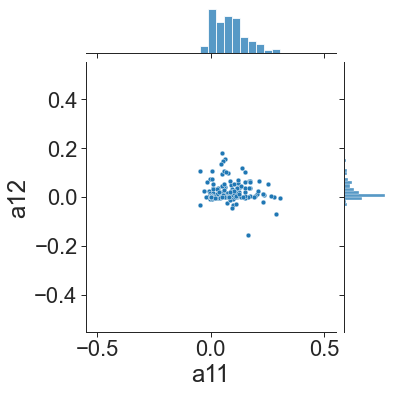

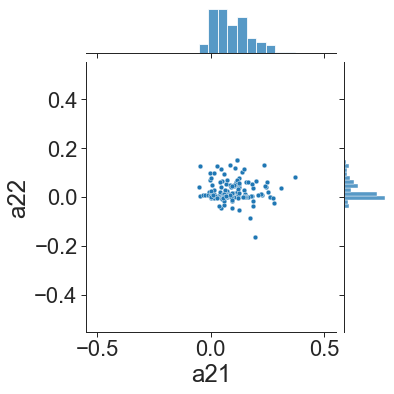

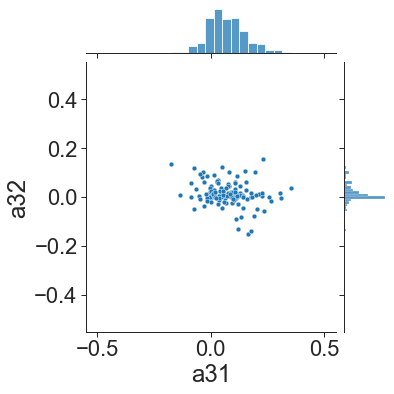

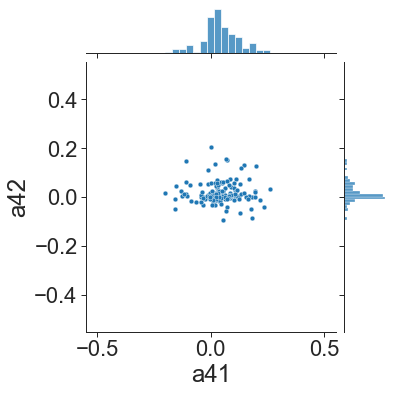

In [6]:
# Elements of Z (EMA and lapse observation matrix)
elems = [1,2,3,4]
sns.set_style('ticks')
sns.set_context('paper',font_scale=2.5)

for i in elems:
    val = i-1
    str1 = 'z'+str(i)+'1'
    str2 = 'z'+str(i)+'2'
    #lims=(minval-.1,maxval+.1)
    lims=(-.55,.55)
    x = val // 2
    y = val % 2 
    h=sns.jointplot(data=coefs,x=str1,y=str2,xlim=lims,ylim=lims)
    h.set_axis_labels('a{}1'.format(str(i)), 'a{}2'.format(str(i)))
    save_str = "plots/norm_a{}.pdf".format(i)
    plt.savefig(save_str,bbox_inches='tight',facecolor='w')
    # print("E[{}] = ".format(str1),np.mean(coefs[str1]))
    # print("E[{}] = ".format(str2),np.mean(coefs[str2]))
    # print("---")
None

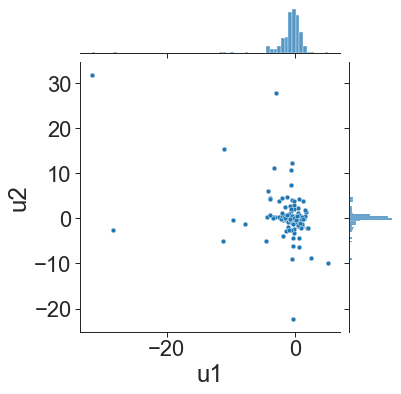

In [15]:
sns.jointplot(data=coefs,x='u1',y='u2')

#plt.savefig("plots/trunc_norm_b.pdf",bbox_inches='tight',facecolor='w')
None

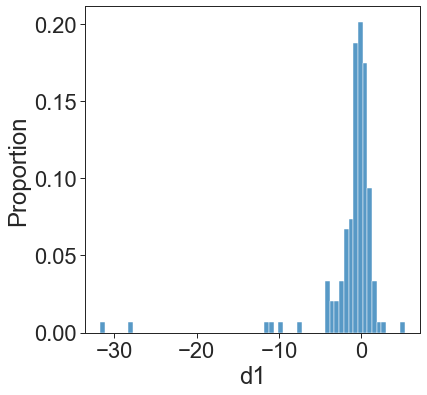

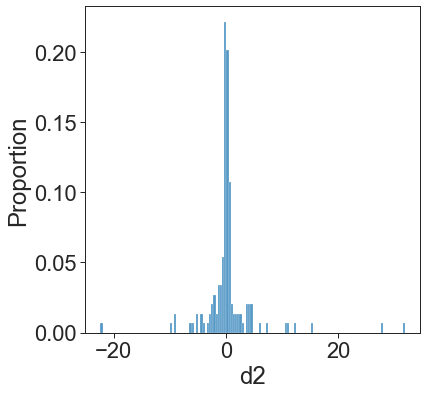

In [17]:
for i in [1,2]:
    str1 = 'u'+str(i)
    fig,ax=plt.subplots(figsize=(6,6))
    h=sns.histplot(data=coefs,x=str1,ax=ax,stat='proportion')
    h.set_xlabel('d{}'.format(str(i)))
    save_str = "plots/norm_d{}.pdf".format(i)
    plt.savefig(save_str,bbox_inches='tight',facecolor='w')
    #ax.set_title('Distribution of {}'.format(str1))
    #print("E[{}] = ".format(str1),np.mean(coefs[str1]))

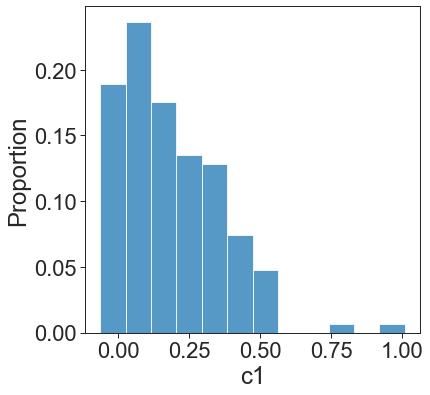

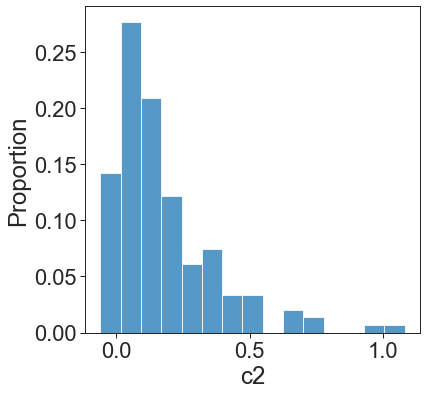

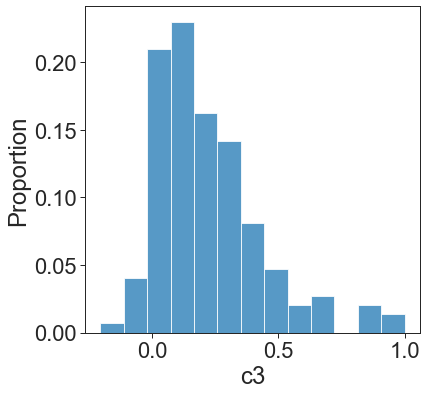

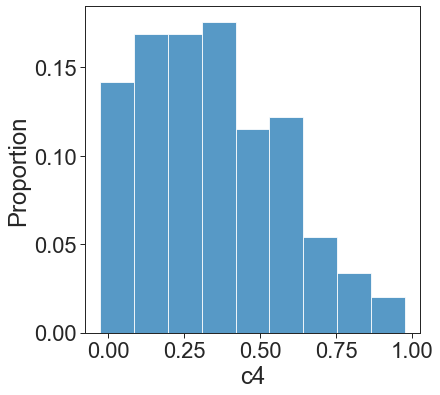

In [7]:
for i in [1,2,3,4]:
    str1 = 'a'+str(i)
    fig,ax=plt.subplots(figsize=(6,6))
    h=sns.histplot(data=coefs,x=str1,ax=ax,stat='proportion')
    h.set_xlabel('c{}'.format(str(i)))
    save_str = "plots/norm_c{}.pdf".format(i)
    plt.savefig(save_str,bbox_inches='tight',facecolor='w')
    #ax.set_title('Distribution of {}'.format(str1))
    #print("E[{}] = ".format(str1),np.mean(coefs[str1]))

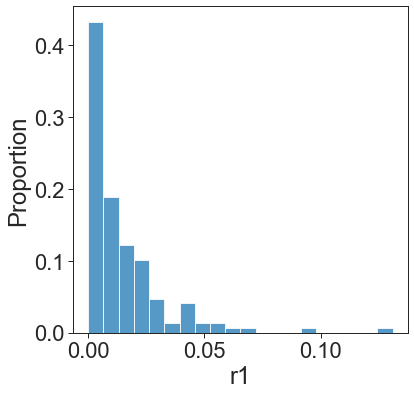

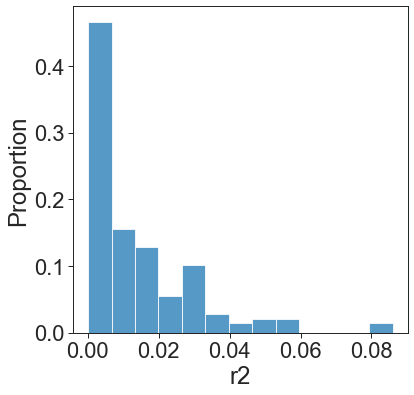

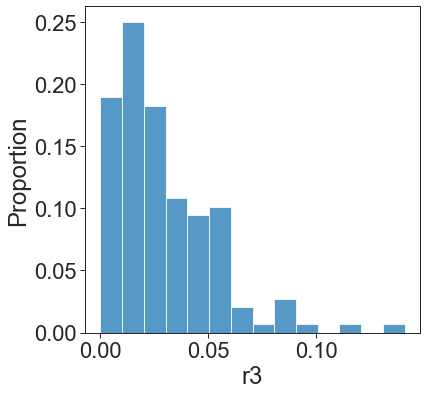

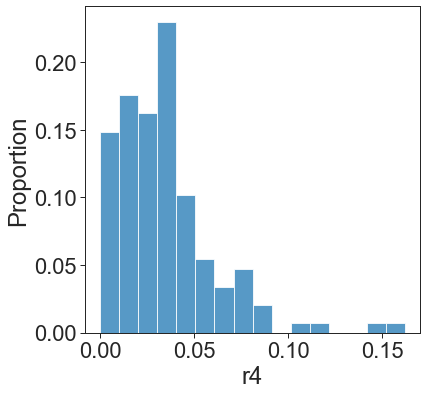

In [8]:
for i in [1,2,3,4]:
    str1 = 'r'+str(i)
    fig,ax=plt.subplots(figsize=(6,6))
    h=sns.histplot(data=coefs,x=str1,ax=ax,stat='proportion')
    h.set_xlabel('r{}'.format(str(i)))
    save_str = "plots/norm_r{}.pdf".format(i)
    plt.savefig(save_str,bbox_inches='tight',facecolor='w')
    #ax.set_title('Distribution of {}'.format(str1))
    #print("E[{}] = ".format(str1),np.mean(coefs[str1]))

In [39]:
coefs[abs(coefs.u1)>=10]

,Unnamed: 0,id,mema_count,fit_var,z11,z21,z31,z41,z51,z61,z71,z81,z91,z101,z12,z22,z32,z42,z52,z62,z72,z82,z92,z102,a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,r1,r2,r3,r4,r5,r6,r7,r8,r9,b11,b22,u1,u2
10,11,16,67,False,0.092714,0.102400,0.030740,0.060263,-0.002451,-0.016389,0.024097,-0.001342,0.019101,7.267576e-02,-0.001322,-0.002525,-0.003646,-0.007681,0.006253,0.005077,-0.001749,0.000037,0.011469,4.771539e-03,1.009128,1.081624,0.308559,0.766555,0.989031,0.521595,0.938396,0.761410,1.037199,1.123421e+00,0.009778,0.017347,0.023267,0.017249,0.011794,0.092567,0.009195,0.010090,0.015266,1.000000e-10,8.959848e-01,-10.926271,-5.190642
45,46,66,43,False,0.059979,0.070214,0.045311,0.033238,-0.023878,-0.058054,0.025598,0.019343,0.018426,1.000000e-10,0.040010,0.048783,0.032515,0.023381,-0.017175,0.051581,-0.016381,-0.019290,-0.018438,-1.168108e-10,0.157310,0.128527,0.087422,0.101289,0.854780,-1.483600,0.914889,0.896787,0.853671,4.502407e-09,0.000704,0.000357,0.001057,0.001706,0.058285,0.100113,0.000910,0.002457,0.000605,3.591410e-01,3.747117e-01,-11.019569,15.338497
78,79,135,75,False,0.003480,0.002857,-0.002708,0.001796,0.038234,0.004727,-0.008841,-0.008386,-0.002064,1.614583e-09,0.003005,0.000382,-0.000690,-0.001703,0.002972,0.005577,0.013039,0.010428,-0.002420,-1.000000e-10,0.037323,0.050608,-0.012309,0.076166,0.997143,0.524777,0.299567,0.337082,0.041730,2.181059e-08,0.000887,0.002191,0.004584,0.012886,0.000100,0.006637,0.015418,0.004087,0.021557,1.000000e-10,1.000000e+00,-13.215321,0.220293
88,89,161,77,False,-0.000880,-0.000880,0.010747,0.022569,0.026624,0.072817,-0.101320,0.053844,-0.028397,3.080902e-03,0.001514,0.001514,0.008446,0.022689,0.018491,0.040591,-0.061295,0.030905,-0.017675,1.786720e-03,0.080499,0.080499,0.322476,0.664360,0.702952,-0.005791,0.600536,0.597791,0.297996,-4.701996e-04,0.000100,0.000100,0.043026,0.038910,0.012239,0.033512,0.013704,0.019775,0.008127,1.291122e-01,1.000000e-10,22.581600,-38.089807
